# 1. Import and Hardware Setup

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt
import numpy as np
import copy

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

!pip install wandb -q
import wandb

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [12]:
DATA_PATH = './Data'
SAVE_PATH = '.Model'

In [13]:
wandb.login()

wandb: WARNING Unable to verify login in offline mode.


False

# 2. Hyperparameters

In [14]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128

EPOCHS = 5
LR = 0.04
NUM_CLS = 101
DROPOUT_RATE = 0.5

# 3. Training Data Preparation

In [15]:
stats = ((0.545, 0.443, 0.344), (0.269, 0.271, 0.276))

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [16]:
# 1. Get indices first (using a dummy dataset to minimize overhead)
# We set download=True here to ensure data exists.
dummy_data = datasets.Food101(root=DATA_PATH, split='train', download=True)

train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size

# random_split returns Subsets, we extract indices from them
train_subset_temp, val_subset_temp = random_split(dummy_data, [train_size, val_size])
train_idx = train_subset_temp.indices
val_idx = val_subset_temp.indices

# 2. Create Clean Datasets with correct transforms
# We create two separate dataset objects so they don't share referencing issues when pickling
train_dataset = datasets.Food101(root=DATA_PATH, split='train', 
                               download=False, transform=train_transform)
val_dataset = datasets.Food101(root=DATA_PATH, split='train', 
                             download=False, transform=test_transform)

# 3. Create Subsets using the indices
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

# 4. Download the test data
test_data = datasets.Food101(root=DATA_PATH, split='test', 
                        download=True, transform=test_transform)

In [ ]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)

# 4. Model Architecture

<table>
  <tr>
    <td><img src="VGG16.png"></td>
    <td><img src="VGG16_2.png"></td>
  </tr>
</table>

In [18]:
class VGG16(nn.Module):
    def __init__(self, in_channels, num_cls, dropout_rate):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            # ---------- 1. Block ---------- 

            # Conv (224x224x3) -> (224x224x64)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Conv (224x224x64) -> (224x224x64)
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Pool (224x224x64) -> (112x112x64)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 2. Block ---------- 

            # Conv (112x112x64) -> (112x112x128)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Conv (112x112x128) - (112x112x128)
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Pool (112x112x128) -> (56x56x128)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 3. Block ---------- 
            # (56x56x128) -> (56x56x256)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # (56x56x256) -> (56x56x256)
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # (56x56x256) -> (56x56x256)
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # (56x56x256) -> (28x28x256)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 4. Block ----------
            # (28x28x256) -> (28x28x512) 
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (28x28x512) -> (28x28x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (28x28x512) -> (28x28x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (28x28x512) -> (14x14x512)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 5. Block ----------
            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # (14x14x512) -> (7x7x512)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(7*7*512, 4096),
            nn.ReLU(),

            nn.Dropout(dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(),

            nn.Linear(4096, num_cls)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)

        return logits

model = VGG16(IN_CHANNELS, NUM_CLS, DROPOUT_RATE).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

Using 2 GPUs!


# 5. Training Preparation

In [19]:
class EarlyStopping:
    def __init__(self, patience=10, delta = 0, verbose = False, save_path='best_model.pth', trace_func=print):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.trace_func = trace_func

        self.best_score = None
        self.earlystop = False
        self.counter = 0

    def __call__(self, val_loss, model):

        # The first epoch
        if self.best_score is None:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)

        # The loss didnt reduce much as expect or increased
        elif val_loss >= self.best_score - self.delta:
            self.counter += 1
            self.trace_func(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if (self.counter >= self.patience):
                self.earlystop = True
        
        # The loss reduced properly
        else:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        if self.verbose:
            self.trace_func("Best Model saving ...")
        torch.save(model.state_dict(), self.save_path)

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience= 5, factor=0.1)

# Using GradScaler to prevent Gradient Underflow by using FP16
scaler = torch.amp.GradScaler(device)

In [21]:
def train(model, loader, criterion, optimizer, scaler):
    # Set the Model in Training Mode
    model.train()

    loop = tqdm(loader, desc="Training", leave=False)
    
    # Initialize accumulators on device to avoid CPU-GPU sync
    train_loss = torch.tensor(0.0, device=device)
    train_acc = torch.tensor(0.0, device=device)

    for x, y in loop:
        # Move data to device
        x, y = x.to(device), y.to(device)

        # Clear the Gradient of last batch
        optimizer.zero_grad(set_to_none=True)

        # Get prediction & loss with Automatic Mixed Precision (AMP)
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Scale down the Gradients before clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Check if the gradients are valid after Unscaling
        scaler.step(optimizer)

        # Adjust the Scale Factor for the next batch
        scaler.update()

        # Sum up the loss and accuracy using local tensor accumulator
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()

    # Move to CPU only at the end
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

In [ ]:
import torch.profiler as profiler

def train_with_profiling(model, loader, criterion, optimizer, scaler):
    # Set the Model in Training Mode
    model.train()
    processed_samples = 0

    # Set up for the profiler
    activities=[profiler.ProfilerActivity.CPU]
    if torch.cuda.is_available():
        activities.append(profiler.ProfilerActivity.CUDA)

    with profiler.profile(
        activities=activities,
        record_shapes = True,
        profile_memory=True,
        with_stack=True
    ) as prof:
        loop = tqdm(loader, desc="Profiling", leave=False)

        for i, (x, y) in enumerate(loop):
            # Move data to device
            x, y = x.to(device), y.to(device)

            # Clear the Gradient of last batch
            optimizer.zero_grad(set_to_none=True)

            # Get prediction & loss with Automatic Mixed Precision (AMP)
            with torch.amp.autocast(device_type=device.type, enabled=True):
                out = model(x)
                loss = criterion(out, y)

            # Scale up the loss and backpropagate
            scaler.scale(loss).backward()

            # Scale down the Gradients before clipping
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Check if the gradients are valid after Unscaling
            scaler.step(optimizer)

            # Adjust the Scale Factor for the next batch
            scaler.update()

            processed_samples += x.size(0)

            prof.step()

            if i >= 5:
                break

    print("\n" + "="*50)
    print("PROFILER: TOP OPERATIONS")
    print("="*50)

    print("\n" + "="*50)
    print("PROFILER: MEMORY USAGE")
    print("="*50)
    print(prof.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=10))

    del prof
    import gc
    gc.collect()
    
    return "Profiling beendet."

In [23]:
def validate(model, loader, criterion):
    model.eval()
    loop = tqdm(loader, desc="Validation", leave=False)
    val_loss, val_acc = 0, 0

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)

        val_loss += loss.item() * x.size(0)
        val_acc += (out.argmax(1) == y).sum().item()
    
    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [24]:
def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc="Testing", leave=False)
    for x, y in loop:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            out = model(x)
        test_acc += (out.argmax(1) == y).sum().item()

    return test_acc / len(loader.dataset)

# 6. Training Loop

In [25]:
# --- Quick Profile Check ---
print("Starting Profiling Check...")
train_with_profiling(model, train_loader, criterion, optimizer, scaler)

Starting Profiling Check...


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Profiling:   0%|          | 0/474 [00:00<?, ?it/s]


PROFILER: TOP OPERATIONS

PROFILER: MEMORY USAGE
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    aten::empty_strided         1.57%     218.838ms         1.66%     231.934ms      24.753us       0.000us         0.00%       0.000us       0.000us     

'Profiling beendet.'

In [26]:
wandb.init(
    project="VGG",
    config={
        "Architecture": "VGG16",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE
    }
)

train_accuracies, test_accuracies = [], []
train_losses, val_losses = [], []

early_stopping = EarlyStopping(patience=10)

for epoch in range(EPOCHS):
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_acc = validate(model,  val_loader, criterion)
    scheduler.step(val_loss)

    test_acc = test(model, test_loader)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    wandb.log({
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    print(f"Epoch: {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " + 
           f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, test_acc: {test_acc:.4f}")

    early_stopping(val_loss, model)

    if early_stopping.earlystop:
        print("Early Stopping")
        break

wandb.finish()

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch: 1/5 - train_loss: 4.6279, val_loss: 4.6117, train_acc: 0.0101, val_acc: 0.0110, test_acc: 0.0130


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch: 5/5 - train_loss: 4.6038, val_loss: 4.5662, train_acc: 0.0158, val_acc: 0.0281, test_acc: 0.0301


lr,▁▁▁▁▁
test_acc,▁▁▅▇█
train_acc,▁▃▃▆█
train_loss,█▆▅▃▁
val_acc,▁▂▅▇█
val_loss,█▇▆▄▁
lr,0.001
test_acc,0.03014
train_acc,0.01579
train_loss,4.60376
val_acc,0.02805


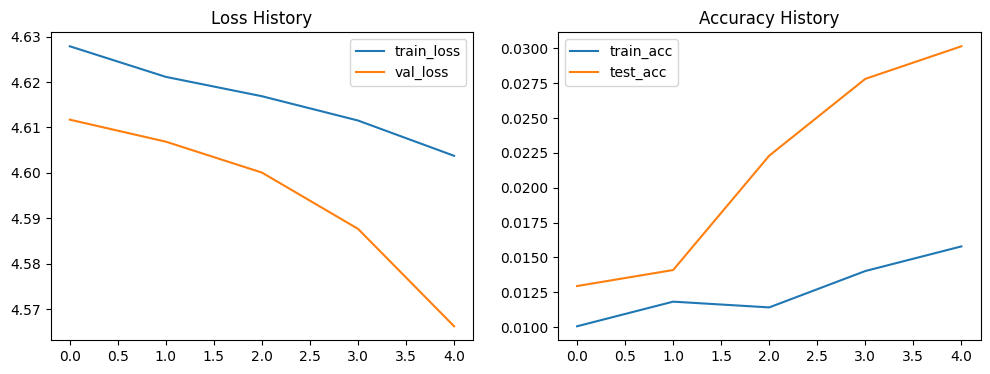

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label = "train_loss")
plt.plot(val_losses, label = "val_loss")
plt.title("Loss History")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = "train_acc")
plt.plot(test_accuracies, label = "test_acc")
plt.title("Accuracy History")
plt.legend()

# 7. GradCAM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


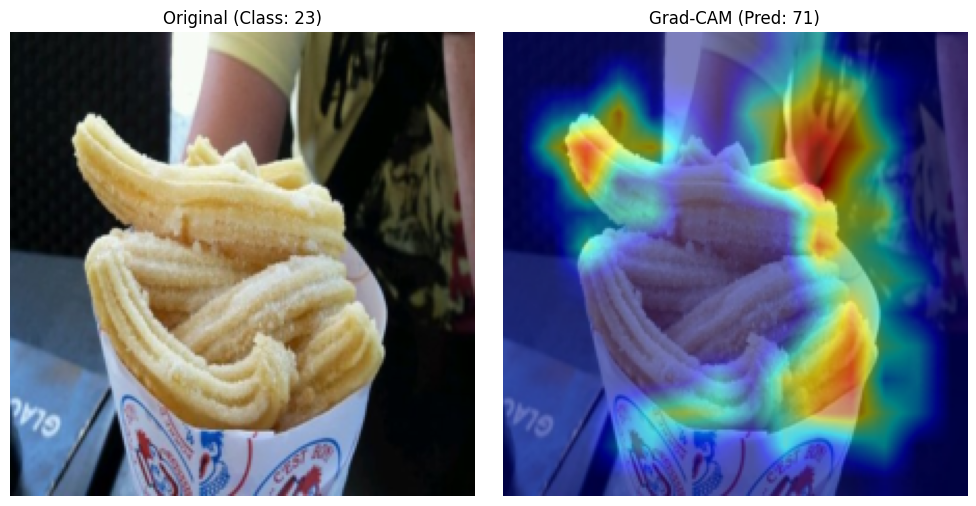

In [28]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

# Pick the last Conv Layer to setup the GradCAM
if isinstance(model, nn.DataParallel):
    target_layers = [model.module.feature_extractor[-3]]
else:
    target_layers = [model.feature_extractor[-3]]
cam = GradCAM(model=model, target_layers=target_layers)

# Pick a random image form the test set
imgs, labels = next(iter(test_loader))
index = random.randint(0, len(imgs) - 1)
input_tensor = imgs[index].unsqueeze(0).to(device)
label = labels[index].item()

# Generate the Grad-CAM heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0, :]

# Prepare the image for Visualization
# create a 1D Tensor from the tuple of per-channel means/std
# and reshape it to (3, 1, 1) because imgs[index] has (3, H, W)
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)
rgb_img = imgs[index] * std + mean # Denormalize
rgb_img = rgb_img.permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1)

# Overlay the heatmap on the image
visual = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Get the Prediction
model.eval()
with torch.no_grad():
    out = model(input_tensor)
    pred = out.argmax(1).item()

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(rgb_img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM (Pred: {pred})")
plt.imshow(visual)
plt.axis('off')
plt.tight_layout()
plt.show()